# Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# 1. Грубая EDA: heart_synth.csv

### Загрузка данных

In [2]:
df = pd.read_csv('../data/heart_synth.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
print('Типы данных:')
df.info()
print()

Типы данных:
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             3000 non-null   int64  
 1   Sex             3000 non-null   str    
 2   ChestPainType   3000 non-null   str    
 3   RestingBP       3000 non-null   int64  
 4   Cholesterol     3000 non-null   int64  
 5   FastingBS       3000 non-null   int64  
 6   RestingECG      3000 non-null   str    
 7   MaxHR           3000 non-null   int64  
 8   ExerciseAngina  3000 non-null   str    
 9   Oldpeak         3000 non-null   float64
 10  ST_Slope        3000 non-null   str    
 11  HeartDisease    3000 non-null   int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 281.4 KB



### Пропуски

In [4]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

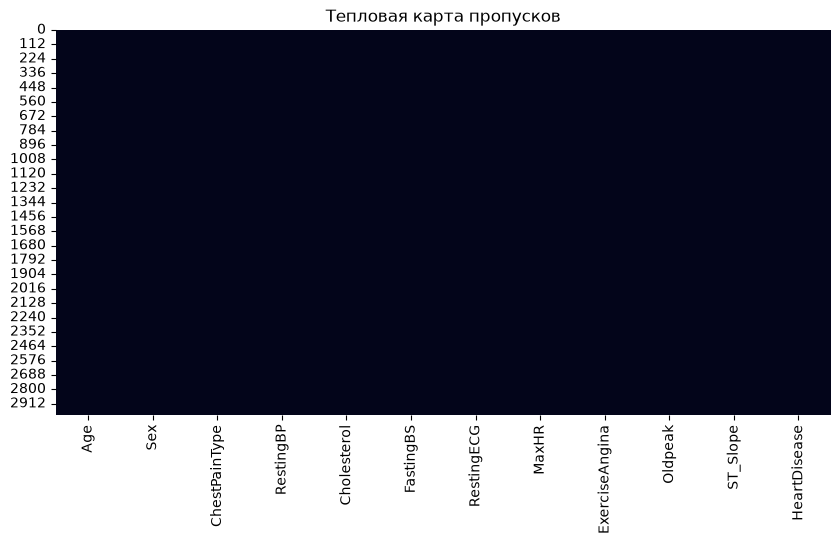

In [5]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isna(), cbar=False)
plt.title('Тепловая карта пропусков')
plt.show()

Пропусков не обнаружено

### Аномальные нули

In [6]:
print(f"RestingBP = 0: {(df['RestingBP'] == 0).sum()} записей")
print(f"Cholesterol = 0: {(df['Cholesterol'] == 0).sum()} записей")

RestingBP = 0: 1 записей
Cholesterol = 0: 549 записей


### Выбросы - гистограммы по числовым колонкам

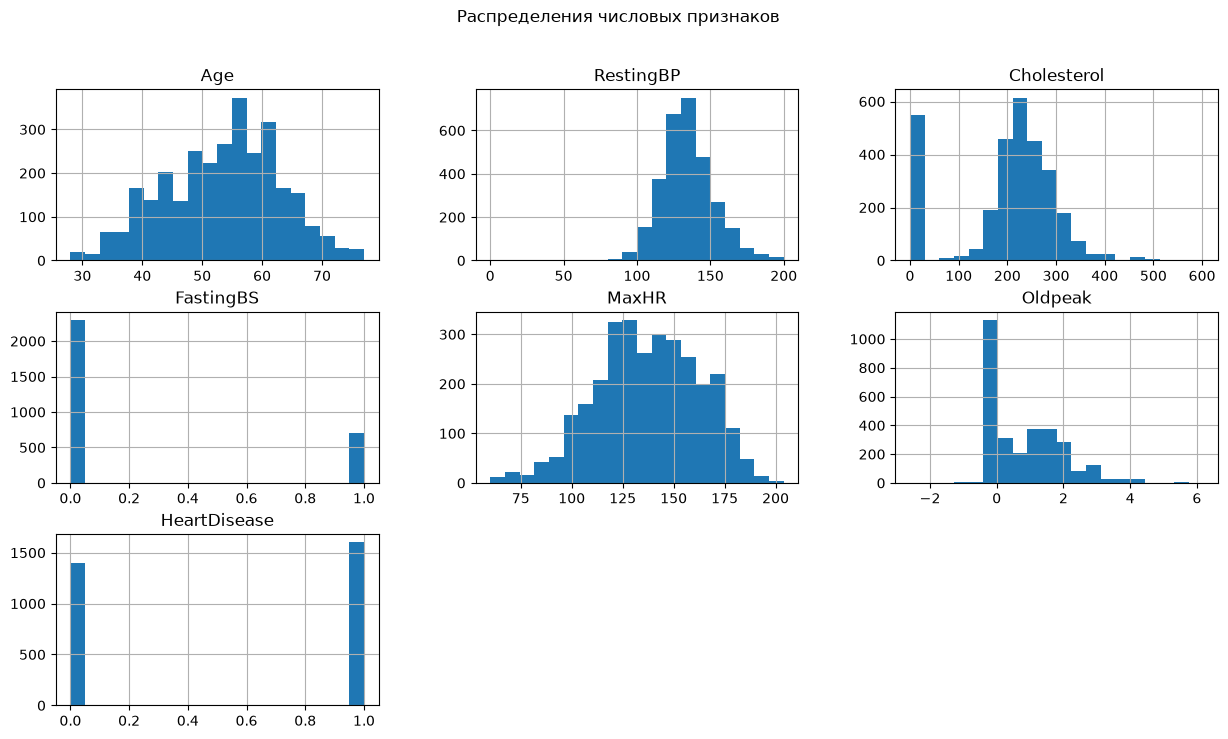

In [7]:
cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'Oldpeak', 'HeartDisease']

df[cols].hist(figsize=(15, 8), bins=20)
plt.suptitle('Распределения числовых признаков')
plt.show()

## Выводы по распределениям

1. **Cholesterol:** явный пик на 0 (~550 записей) - это скрытые пропуски,
   а не реальные значения. Целесообразно заменить медианой.
2. **Oldpeak:** большинство значений = 0, сильная скошенность вправо,
   есть отрицательные значения (~ -2.6).
3. **RestingBP:** основная масса в норме (120-140), правый хвост до 200 -
   выбросы гипертоников.
4. **FastingBS:** принимает только 0 и 1 - бинарный признак,
   обрабатывать как категориальный, а не числовой.
5. **Age, MaxHR:** распределения близки к нормальному, критичных выбросов нет.
6. **HeartDisease:** классы слегка несбалансированы (~45% / 55%) -
   не критично, но оценивать модели целесообразно по F1 и ROC-AUC, а не только Accuracy.

**Итог:** данных достаточно для моделирования, главные проблемы -
нули в Cholesterol и скошенность Oldpeak.

### Корреляции

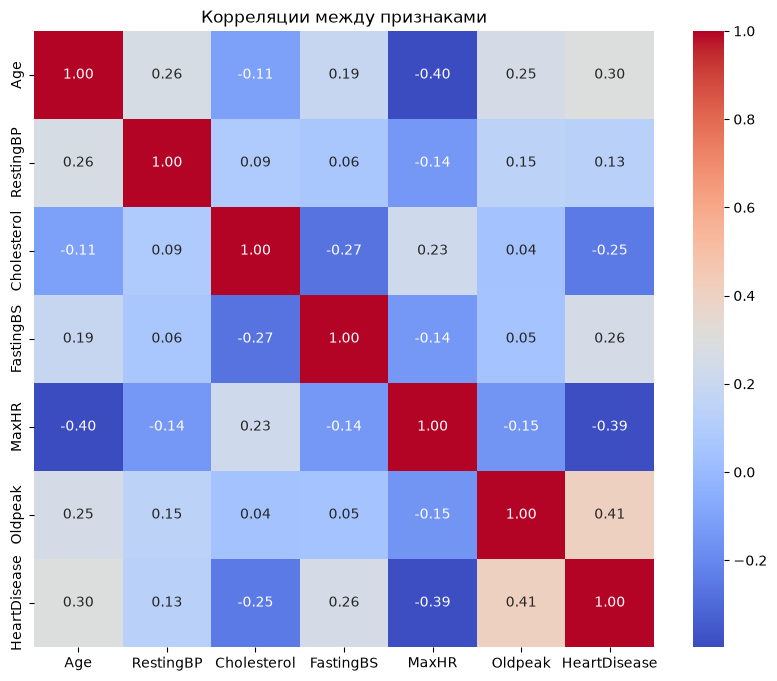

In [8]:
# матрица корреляций
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляции между признаками')
plt.show()

## Выводы по корреляциям

1. **Умеренные связи:** Oldpeak (+0.41), MaxHR (-0.39), Age (+0.30), FastingBS (+0.26), Cholesterol (-0.25).
2. **Слабая связь:** RestingBP (+0.13) - сам по себе признак почти не помогает.
3. **Cholesterol (-0.25) - подозрительный знак:** минус скорее всего из-за нулей (скрытых пропусков).
4. **Мультиколлинеарности нет:** между признаками нет пар с |r| > 0.5, значит удалять дублирующиеся признаки не нужно.
5. **Age и MaxHR (-0.4)** - физиологично: с возрастом максимальный пульс падает.

**Итог:** основные будущие признаки - Oldpeak, MaxHR, Age, FastingBS, Cholesterol.

### Категориальные признаки

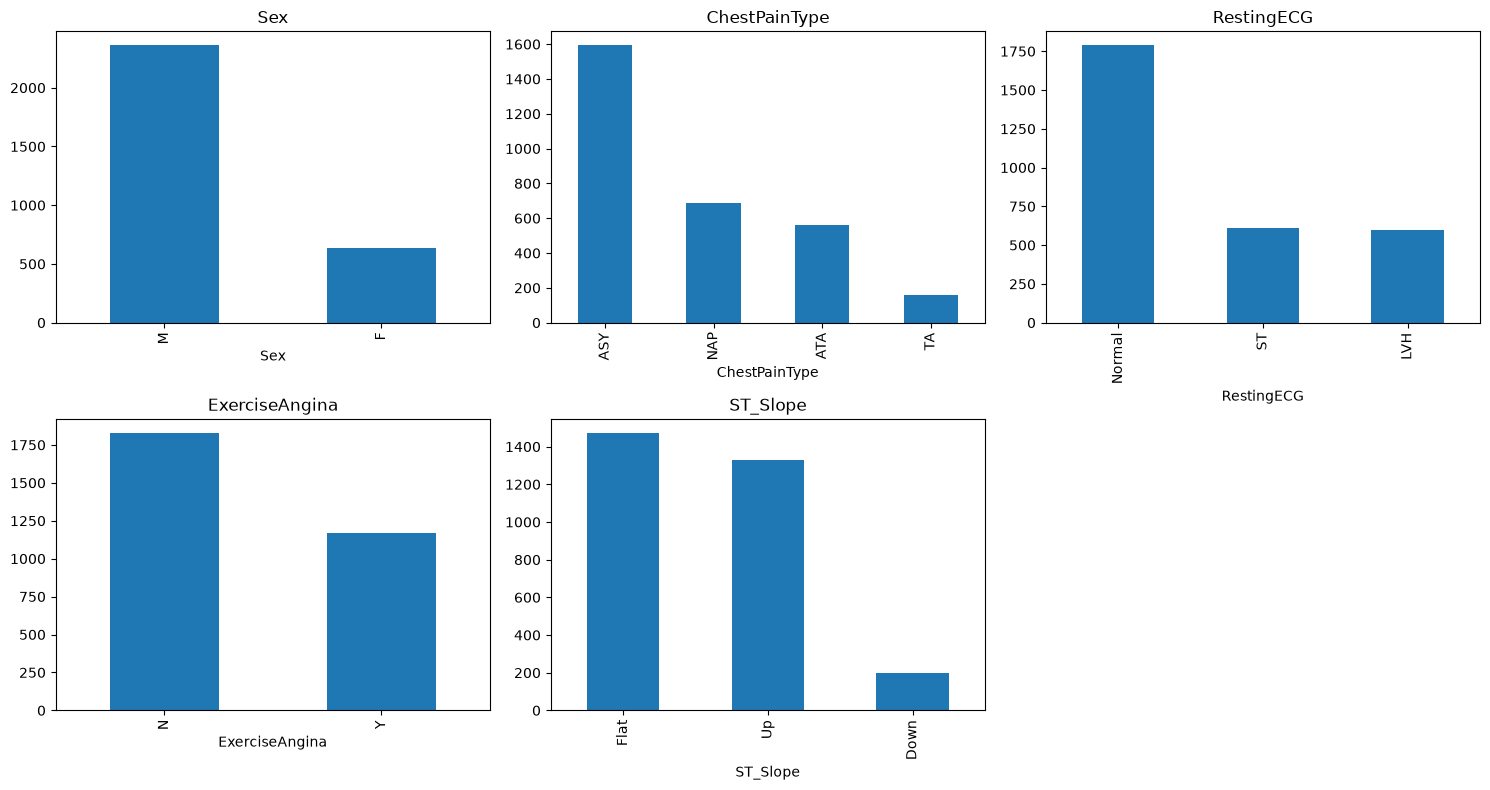

In [9]:
# категориальные признаки
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

### Выводы по категориальным признакам

1. **Sex:** сильный дисбаланс - ~79% мужчин (2370 vs 630).
2. **ChestPainType:** 4 категории, TA - редкая (~150 записей).
3. **RestingECG:** 3 категории, доминирует Normal (~1780).
4. **ExerciseAngina:** фактически бинарный (N/Y) - кодируем просто 0/1.
5. **ST_Slope:** 3 категории, Down - редкая (~200). Признак порядковый, можно закодировать ординально (0/1/2).
6. **Лишних категорий нет:** неизвестных строк и скрытых пропусков не найдено - кодировать можно безопасно.

### Стратегия кодирования:

- Sex, ExerciseAngina - бинарное 0/1
- ChestPainType, RestingECG - one-hot encoding
- ST_Slope - ordinal (0/1/2)

### Целевая переменная - HeartDisease

In [10]:
# баланс классов
df['HeartDisease'].value_counts(normalize=True)

HeartDisease
1    0.533667
0    0.466333
Name: proportion, dtype: float64

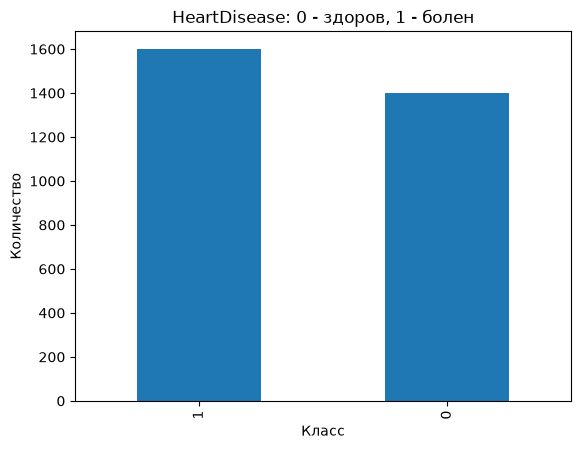

In [11]:
# визуализация
df['HeartDisease'].value_counts().plot(kind='bar')
plt.title('HeartDisease: 0 - здоров, 1 - болен')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.show()

### Выводы по целевой переменной HeartDisease

**Соотношение классов:** 1 - 55.3%,
0 - 44.7%.
Дисбаланс умеренный, не критичный.

# Общие выводы по грубой EDA

## 1. Данные
- 3000 записей, 12 колонок: 11 признаков + целевая HeartDisease.
  (Оригинал с Kaggle — 918 строк, расширен до 3000 бутстрапом с малым
  гауссовским шумом, распределения и баланс классов сохранены.)
- Явных NaN нет, но есть скрытые пропуски, замаскированные под нули.

## 2. Главные проблемы данных
- **Cholesterol = 0** (~550 записей) - физически невозможно, это скрытые пропуски.
- **Oldpeak** - отрицательные значения (~ -2.6) и сильная скошенность вправо, большинство значений = 0.
- **RestingBP** - правый хвост до 200 (вероятно гипертоники), выбросы, нули проверить отдельно.
- **FastingBS** - принимает только 0/1, это бинарный признак, а не числовой.
- **Категории несбалансированы:** Sex ~79% мужчин (2370 vs 630), редкие категории TA (~150) и Down (~200).

## 3. Связи
- Сильнейшие связи с HeartDisease: **Oldpeak (+0.41)** и **MaxHR (−0.39)**.
- Умеренные: Age (+0.30), FastingBS (+0.26). RestingBP слабый (+0.13).
- Мультиколлинеарности нет (все |r| < 0.5 между признаками) - удалять признаки не нужно.
- Корреляция Cholesterol (−0.25) - артефакт нулей, перепроверить после очистки.

## 4. Целевая переменная и метрики
- Классы: 55.3% больны (~1660), 44.7% здоровы (~1340) - дисбаланс умеренный.

## 5. План предобработки (переход к п. 2.b)
1. Нули в Cholesterol (и RestingBP, если есть) - считать пропусками, заменить медианой.
2. Отрицательный Oldpeak - проверить и ограничить/заменить.
3. Кодирование: Sex, ExerciseAngina - 0/1, ChestPainType, RestingECG - one-hot, ST_Slope - ordinal (0/1/2).
4. Масштабирование числовых - только для линейных моделей (LogReg), древесным не нужно.
5. Редкие категории (TA, Down) оставить, но следить за ними на этапе моделей.

## Итог
Данные пригодны для моделирования после очистки.

# 2. Кодирование, масштабирование, очистка

### Разделение на train/test

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='HeartDisease')
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(2400, 11) (600, 11)


### Очистка

In [13]:
# медианы считаем ТОЛЬКО по train
medians = {col: X_train[col].replace(0, np.nan).median()
           for col in ['Cholesterol', 'RestingBP']}

def clean(part, medians):
    part = part.copy()
    # нули = скрытые пропуски, заполняем медианой с train
    for col in ['Cholesterol', 'RestingBP']:
        part[col] = part[col].replace(0, np.nan).fillna(medians[col])
    # отрицательная ST-депрессия невозможна
    part['Oldpeak'] = part['Oldpeak'].clip(lower=0)
    return part

X_train = clean(X_train, medians)
X_test = clean(X_test, medians)

### Кодирование

In [14]:
def encode(part):
    part = part.copy()
    part['Sex'] = (part['Sex'] == 'M').astype(int)
    part['ExerciseAngina'] = (part['ExerciseAngina'] == 'Y').astype(int)
    part['ST_Slope'] = part['ST_Slope'].map({'Up': 0, 'Flat': 1, 'Down': 2})
    part = pd.get_dummies(part, columns=['ChestPainType', 'RestingECG'],
                          drop_first=True, dtype=int)  # сразу 0/1, а не True/False
    return part

X_train = encode(X_train)
X_test = encode(X_test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

### Масштабирование

In [15]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])  # fit на train
X_test[num_cols] = scaler.transform(X_test[num_cols])        # тот же scaler на test

### Проверка результата

In [16]:
print('nan в train:', X_train.isna().sum().sum(), '| nan в test:', X_test.isna().sum().sum())
print('колонок:', X_train.shape[1])
print('нечисловые колонки:', X_train.select_dtypes(exclude='number').columns.tolist())
X_train.head()

nan в train: 0 | nan в test: 0
колонок: 14
нечисловые колонки: []


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
1927,0.362914,1,1.105026,0.490173,0,-1.989307,1,0.291276,1,0,0,0,1,0
289,-1.821853,1,-0.722565,-1.442437,0,1.688857,0,-0.872696,0,1,0,0,1,0
1230,-1.197634,1,-0.779677,-0.898304,0,0.621003,0,-0.775699,0,1,0,0,1,0
2875,1.507316,1,0.933690,-0.860778,1,-0.170000,0,-0.872696,1,0,1,0,1,0
1612,0.779060,1,0.476792,-0.898304,1,-1.396054,0,0.582269,2,0,0,1,0,1


### Выводы: кодирование, масштабирование, очистка (п. 2.c)

1. **Очистка:** нули в Cholesterol/RestingBP заменены медианой (считалась по train),
   отрицательный Oldpeak обрезан до 0.
2. **Кодирование:** Sex и ExerciseAngina - 0/1, ST_Slope - ordinal 0/1/2,
   ChestPainType и RestingECG - one-hot с drop_first.
3. **Масштабирование:** StandardScaler для 5 числовых признаков, fit только на train.
4. **Утечек нет:** все преобразователи обучены на train и применены к test без изменений.
5. **Итог:** пропусков нет, все признаки числовые - данные готовы к Этапу 2 (модели).

In [17]:
os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# параметры преобразований — для инференса на новых данных
pd.Series(medians, name='median').to_csv('../data/processed/medians.csv')
pd.DataFrame({'mean': scaler.mean_, 'scale': scaler.scale_},
             index=num_cols).to_csv('../data/processed/scaler.csv')

print('сохранено:', os.listdir('../data/processed'))

сохранено: ['medians.csv', 'scaler.csv', 'X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv']
